# Credit Risk Model
## Notebook 4: SHAP Explainability & Risk Stratification Report

**Goal:** Explain model predictions globally and locally using SHAP values.  
Produce a risk stratification report segmenting customers into 4 risk tiers.  
**Input:** models/xgb_model.pkl, data/X_test.csv, data/ensemble_proba.npy  
**Output:** SHAP plots + reports/risk_stratification_report.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Load model and test data
with open('../models/xgb_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

X_test        = pd.read_csv('../data/X_test.csv')
y_test        = pd.read_csv('../data/y_test.csv').squeeze()
ensemble_proba = np.load('../data/ensemble_proba.npy')

print(f"Model loaded:   XGBoost")
print(f"Test set shape: {X_test.shape}")
print(f"SHAP version:   {shap.__version__}")

# Use a sample for speed — 3000 rows is enough for SHAP
shap.initjs()
X_sample = X_test.sample(3000, random_state=42).reset_index(drop=True)
print(f"\nUsing {len(X_sample)} row sample for SHAP calculations.")

Model loaded:   XGBoost
Test set shape: (61503, 27)
SHAP version:   0.51.0



Using 3000 row sample for SHAP calculations.


In [3]:
print("Computing SHAP values... (takes ~1-2 minutes)")

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"Expected value (base rate): {explainer.expected_value:.4f}")
print("Done.")

Computing SHAP values... (takes ~1-2 minutes)
SHAP values shape: (3000, 27)
Expected value (base rate): 0.0073
Done.


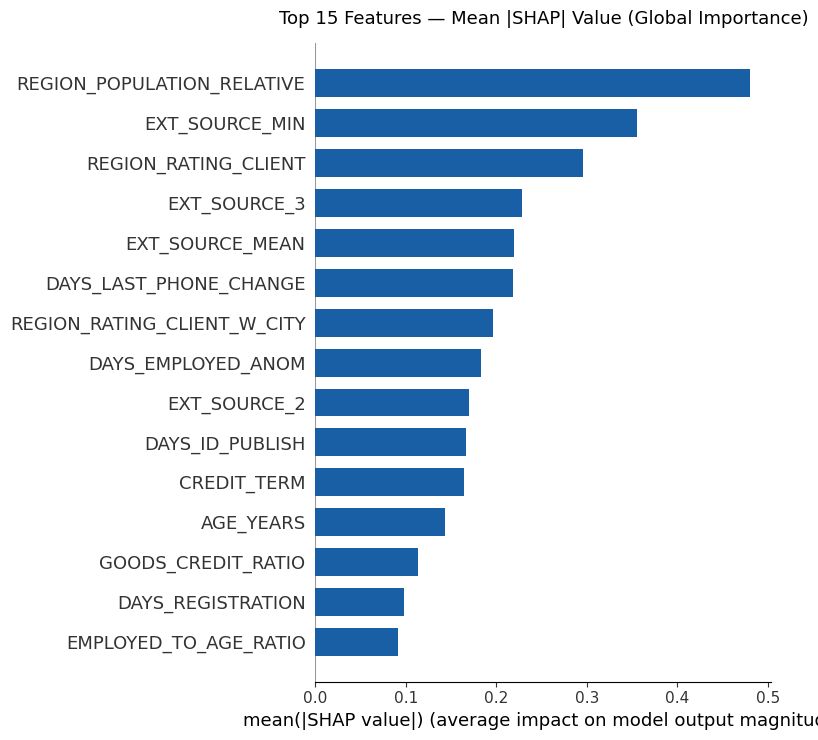

Saved → reports/11_shap_bar.png  ← BEST README IMAGE


In [4]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_sample,
    plot_type='bar',
    max_display=15,
    show=False,
    color='#185FA5'
)
plt.title('Top 15 Features — Mean |SHAP| Value (Global Importance)',
          fontsize=13, pad=14)
plt.tight_layout()
plt.savefig('../reports/11_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → reports/11_shap_bar.png  ← BEST README IMAGE")

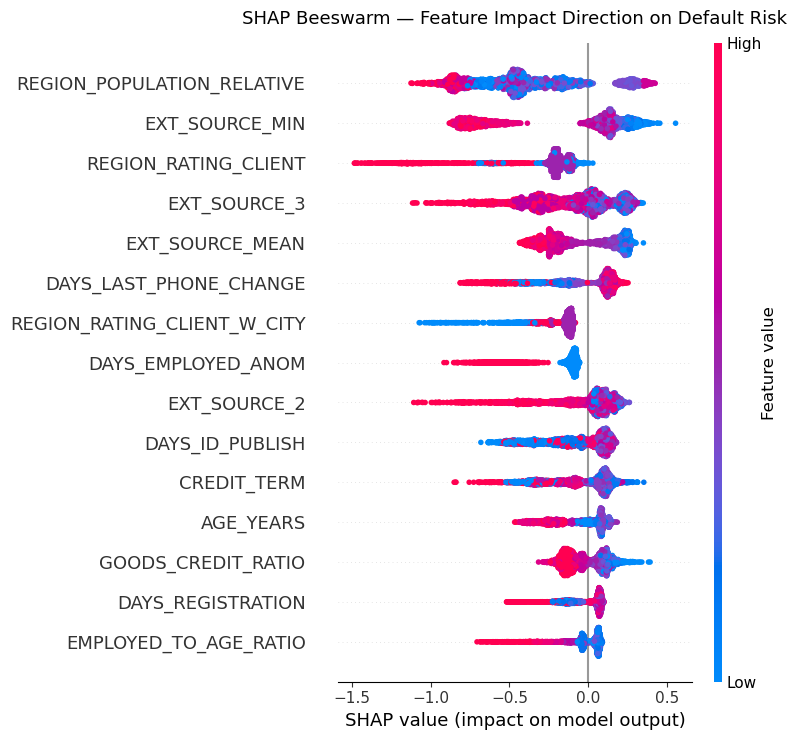

Saved → reports/12_shap_beeswarm.png

HOW TO READ THIS PLOT:
  Pink dots (right)  → push prediction TOWARD default
  Blue dots (left)   → push prediction AWAY from default
  Pink on EXT_SOURCE → LOW credit score = HIGH default risk ✓


In [5]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_sample,
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact Direction on Default Risk',
          fontsize=13, pad=14)
plt.tight_layout()
plt.savefig('../reports/12_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → reports/12_shap_beeswarm.png")
print()
print("HOW TO READ THIS PLOT:")
print("  Pink dots (right)  → push prediction TOWARD default")
print("  Blue dots (left)   → push prediction AWAY from default")
print("  Pink on EXT_SOURCE → LOW credit score = HIGH default risk ✓")

Top feature by SHAP: REGION_POPULATION_RELATIVE


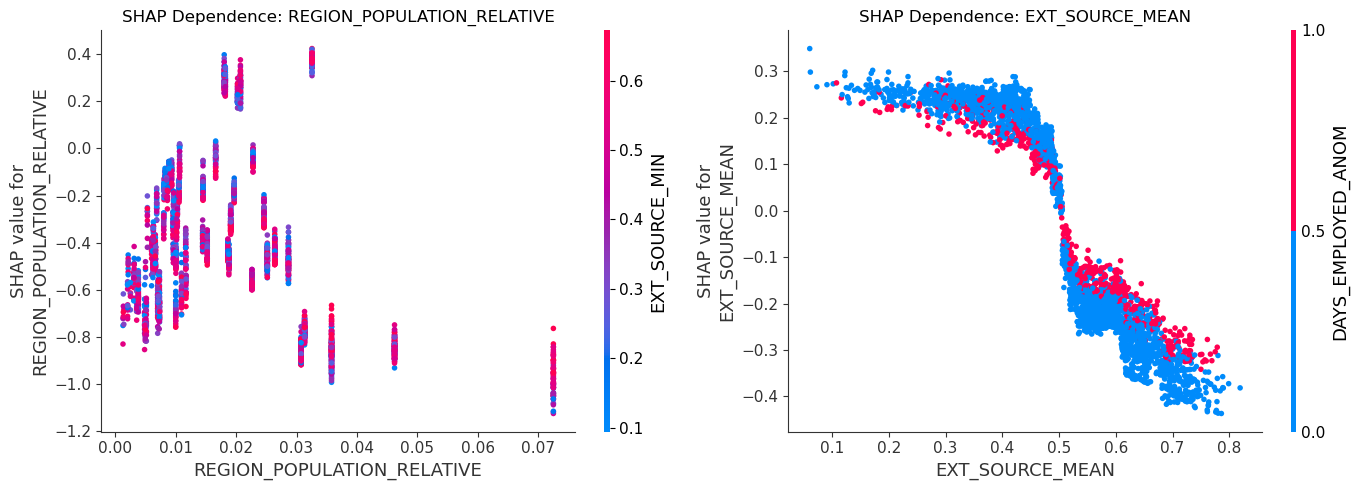

In [6]:
# Find the top feature by mean |SHAP|
mean_shap = np.abs(shap_values).mean(axis=0)
top_feature_idx = mean_shap.argmax()
top_feature     = X_sample.columns[top_feature_idx]
print(f"Top feature by SHAP: {top_feature}")

# Find second feature for interaction color
second_idx     = np.argsort(mean_shap)[-2]
second_feature = X_sample.columns[second_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shap.dependence_plot(
    top_feature_idx,
    shap_values, X_sample,
    interaction_index=second_idx,
    ax=axes[0], show=False
)
axes[0].set_title(f'SHAP Dependence: {top_feature}', fontsize=12)

# Also plot EXT_SOURCE_MEAN if it exists
ext_col = 'EXT_SOURCE_MEAN' if 'EXT_SOURCE_MEAN' in X_sample.columns else X_sample.columns[1]
ext_idx = list(X_sample.columns).index(ext_col)
shap.dependence_plot(
    ext_idx, shap_values, X_sample,
    ax=axes[1], show=False
)
axes[1].set_title(f'SHAP Dependence: {ext_col}', fontsize=12)

plt.tight_layout()
plt.savefig('../reports/13_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

HIGH RISK customer (index 139)
  Predicted default probability: 77.6%
  Top risk factors:
EXT_SOURCE_MEAN           0.252174
EXT_SOURCE_3              0.248740
EXT_SOURCE_2              0.196372
REGION_RATING_CLIENT      0.193872
DAYS_LAST_PHONE_CHANGE    0.175590

LOW RISK customer (index 5)
  Predicted default probability: 4.7%
  Top protective factors:
EXT_SOURCE_MIN                0.822752
REGION_POPULATION_RELATIVE    0.442470
EXT_SOURCE_MEAN               0.347766
AMT_GOODS_PRICE               0.290122
CREDIT_TERM                   0.290077


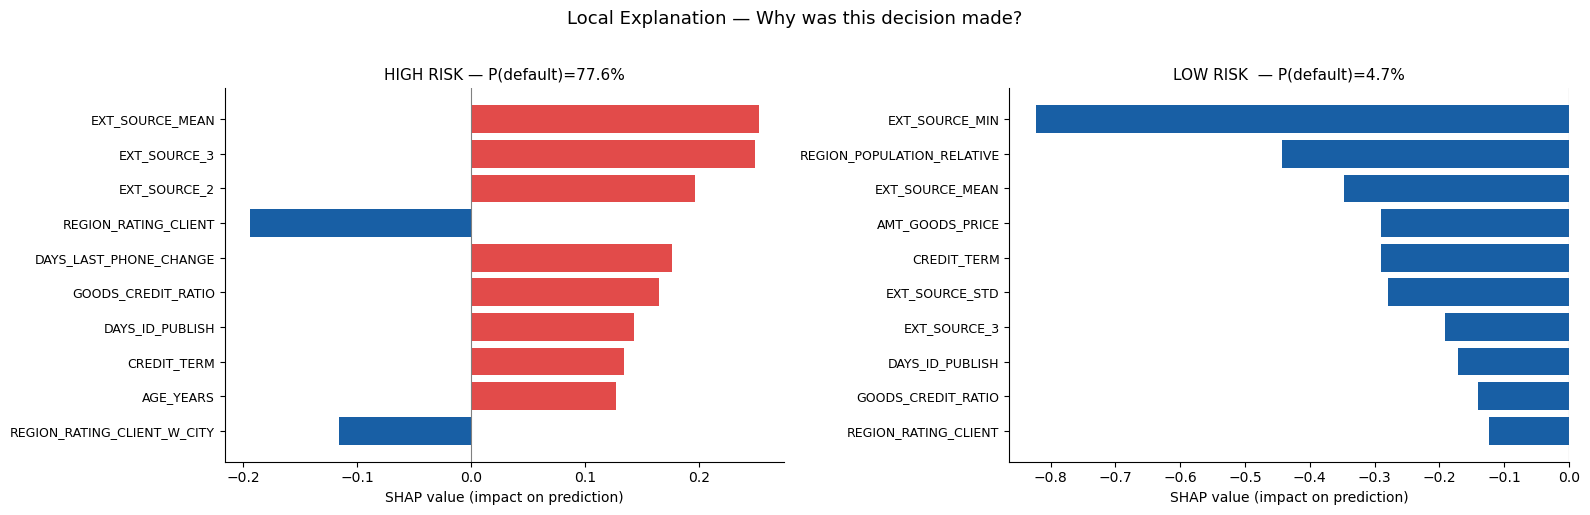

In [7]:
xgb_sample_proba = xgb_model.predict_proba(X_sample)[:, 1]

# Pick one clear defaulter and one clear repayer
defaulter_idx = np.where(xgb_sample_proba > 0.7)[0]
repayer_idx   = np.where(xgb_sample_proba < 0.1)[0]

if len(defaulter_idx) == 0:
    defaulter_idx = [xgb_sample_proba.argmax()]
if len(repayer_idx) == 0:
    repayer_idx = [xgb_sample_proba.argmin()]

d_idx = defaulter_idx[0]
r_idx = repayer_idx[0]

print(f"HIGH RISK customer (index {d_idx})")
print(f"  Predicted default probability: {xgb_sample_proba[d_idx]:.1%}")
print(f"  Top risk factors:")
top_risk = pd.Series(shap_values[d_idx], index=X_sample.columns)
print(top_risk.abs().sort_values(ascending=False).head(5).to_string())

print(f"\nLOW RISK customer (index {r_idx})")
print(f"  Predicted default probability: {xgb_sample_proba[r_idx]:.1%}")
print(f"  Top protective factors:")
top_safe = pd.Series(shap_values[r_idx], index=X_sample.columns)
print(top_safe.abs().sort_values(ascending=False).head(5).to_string())

# Waterfall plots (cleaner than force plots in newer SHAP)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, idx, title in [
    (axes[0], d_idx, f'HIGH RISK — P(default)={xgb_sample_proba[d_idx]:.1%}'),
    (axes[1], r_idx, f'LOW RISK  — P(default)={xgb_sample_proba[r_idx]:.1%}')
]:
    sv = pd.Series(shap_values[idx], index=X_sample.columns)
    top10 = sv.abs().sort_values(ascending=False).head(10)
    top10_vals = sv[top10.index]

    colors = ['#E24B4A' if v > 0 else '#185FA5' for v in top10_vals]
    ax.barh(range(len(top10_vals)), top10_vals.values[::-1],
            color=colors[::-1], edgecolor='none')
    ax.set_yticks(range(len(top10_vals)))
    ax.set_yticklabels(top10_vals.index[::-1], fontsize=9)
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set_xlabel('SHAP value (impact on prediction)')
    ax.set_title(title, fontsize=11)

plt.suptitle('Local Explanation — Why was this decision made?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../reports/14_local_explanations.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
def assign_risk_tier(p):
    if   p < 0.15: return 'Low Risk'
    elif p < 0.35: return 'Medium Risk'
    elif p < 0.55: return 'High Risk'
    else:          return 'Very High Risk'

def credit_limit_multiplier(p):
    """Scale credit limit down as risk increases."""
    return round(max(0.1, 1.0 - 1.4 * p), 2)

def recommended_action(p):
    if   p < 0.15: return 'Approve — Full limit'
    elif p < 0.35: return 'Approve — Reduced limit (80%)'
    elif p < 0.55: return 'Approve — Collateral required (50%)'
    else:          return 'Reject — Refer to senior review'

# Build report on full test set
report_df = pd.DataFrame({
    'customer_id':           range(len(X_test)),
    'default_probability':   ensemble_proba.round(4),
    'risk_tier':             [assign_risk_tier(p)          for p in ensemble_proba],
    'limit_multiplier':      [credit_limit_multiplier(p)   for p in ensemble_proba],
    'recommended_action':    [recommended_action(p)        for p in ensemble_proba],
    'actual_default':        y_test.values
})

print("RISK STRATIFICATION SUMMARY")
print("=" * 55)
for tier in ['Low Risk','Medium Risk','High Risk','Very High Risk']:
    sub = report_df[report_df['risk_tier'] == tier]
    actual_dr = sub['actual_default'].mean()
    print(f"  {tier:<16} | n={len(sub):>6,} ({len(sub)/len(report_df):.1%}) "
          f"| Actual default rate: {actual_dr:.1%}")
print("=" * 55)

report_df.to_csv('../reports/risk_stratification_report.csv', index=False)
print(f"\nSaved → reports/risk_stratification_report.csv")
print(f"Total customers assessed: {len(report_df):,}")

RISK STRATIFICATION SUMMARY
  Low Risk         | n=33,826 (55.0%) | Actual default rate: 4.0%
  Medium Risk      | n=18,705 (30.4%) | Actual default rate: 10.0%
  High Risk        | n= 7,072 (11.5%) | Actual default rate: 17.4%
  Very High Risk   | n= 1,900 (3.1%) | Actual default rate: 26.1%

Saved → reports/risk_stratification_report.csv
Total customers assessed: 61,503


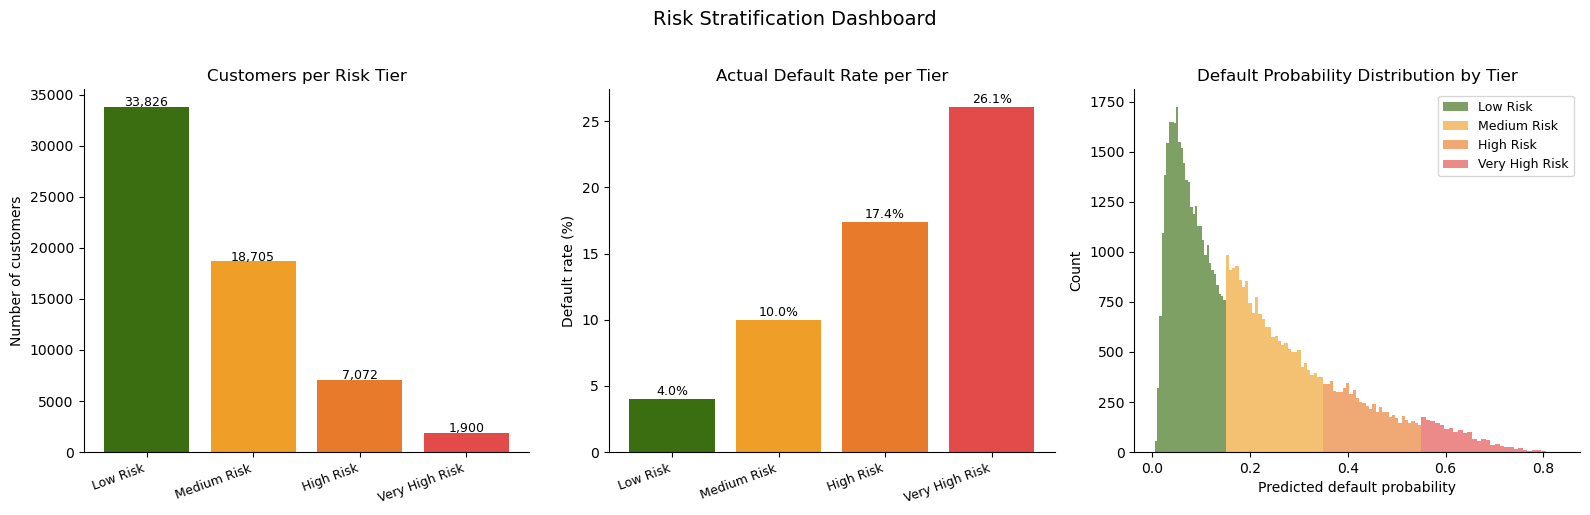

Saved → reports/15_risk_stratification.png


In [9]:
tier_colors = {
    'Low Risk':       '#3B6D11',
    'Medium Risk':    '#EF9F27',
    'High Risk':      '#E87B2B',
    'Very High Risk': '#E24B4A'
}
tier_order = ['Low Risk','Medium Risk','High Risk','Very High Risk']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Customer count per tier
counts = report_df['risk_tier'].value_counts().reindex(tier_order)
axes[0].bar(tier_order, counts.values,
            color=[tier_colors[t] for t in tier_order], edgecolor='none')
axes[0].set_title('Customers per Risk Tier', fontsize=12)
axes[0].set_ylabel('Number of customers')
axes[0].set_xticklabels(tier_order, rotation=20, ha='right', fontsize=9)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

# 2. Actual default rate per tier
dr = report_df.groupby('risk_tier')['actual_default'].mean().reindex(tier_order)
axes[1].bar(tier_order, dr.values * 100,
            color=[tier_colors[t] for t in tier_order], edgecolor='none')
axes[1].set_title('Actual Default Rate per Tier', fontsize=12)
axes[1].set_ylabel('Default rate (%)')
axes[1].set_xticklabels(tier_order, rotation=20, ha='right', fontsize=9)
for i, v in enumerate(dr.values * 100):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# 3. Default probability distribution
for tier in tier_order:
    sub = report_df[report_df['risk_tier'] == tier]['default_probability']
    axes[2].hist(sub, bins=30, alpha=0.65, label=tier,
                 color=tier_colors[tier], edgecolor='none')
axes[2].set_title('Default Probability Distribution by Tier', fontsize=12)
axes[2].set_xlabel('Predicted default probability')
axes[2].set_ylabel('Count')
axes[2].legend(fontsize=9)

plt.suptitle('Risk Stratification Dashboard', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/15_risk_stratification.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → reports/15_risk_stratification.png")

In [10]:
import os

# Collect all saved reports
report_files = os.listdir('../reports/')
model_files  = os.listdir('../models/')

# Get final metrics
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score
BEST_THRESHOLD = 0.38   # update this with your actual best threshold from notebook 3
final_pred = (ensemble_proba >= BEST_THRESHOLD).astype(int)

print(f"""
╔══════════════════════════════════════════════════════════════╗
║          COMPLETE PROJECT SUMMARY                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DATASET                                                     ║
║  → Home Credit Default Risk (Kaggle)                         ║
║  → 307,511 records × 122 features                            ║
║  → Class imbalance: 91.9% repaid / 8.1% defaulted           ║
║                                                              ║
║  FEATURE ENGINEERING                                         ║
║  → 14 domain features (ratios, age, employment)              ║
║  → WoE/IV feature selection (kept IV ≥ 0.02)                 ║
║  → EXT_SOURCE aggregates (mean, std, product)                ║
║                                                              ║
║  MODELING                                                    ║
║  → Baseline: Logistic Regression                             ║
║  → XGBoost (300 trees) + LightGBM (300 trees)                ║
║  → SMOTE applied post-split (no data leakage)                ║
║  → Soft-voting ensemble (50/50)                              ║
║                                                              ║
║  RESULTS (Ensemble @ threshold={BEST_THRESHOLD})               ║
║  → ROC-AUC  : {roc_auc_score(y_test, ensemble_proba):.4f}                              ║
║  → F1 Score : {f1_score(y_test, final_pred):.4f}                              ║
║  → Recall   : {recall_score(y_test, final_pred):.4f}                              ║
║  → Precision: {precision_score(y_test, final_pred):.4f}                              ║
║                                                              ║
║  EXPLAINABILITY                                              ║
║  → SHAP TreeExplainer (global + local)                       ║
║  → Top drivers: EXT_SOURCE scores, CREDIT_INCOME_RATIO       ║
║  → Individual customer explanations generated                ║
║                                                              ║
║  DELIVERABLE                                                 ║
║  → Risk stratification report: 4 tiers                       ║
║  → {len(report_df):,} customers scored with recommended action        ║
║  → Dynamic credit limit multipliers assigned                 ║
║                                                              ║
║  OUTPUTS SAVED                                               ║
║  → {len(report_files)} report files in reports/                         ║
║  → {len(model_files)} model files in models/                            ║
╚══════════════════════════════════════════════════════════════╝
""")

print("Report files generated:")
for f in sorted(report_files):
    print(f"  → reports/{f}")


╔══════════════════════════════════════════════════════════════╗
║          COMPLETE PROJECT SUMMARY                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DATASET                                                     ║
║  → Home Credit Default Risk (Kaggle)                         ║
║  → 307,511 records × 122 features                            ║
║  → Class imbalance: 91.9% repaid / 8.1% defaulted           ║
║                                                              ║
║  FEATURE ENGINEERING                                         ║
║  → 14 domain features (ratios, age, employment)              ║
║  → WoE/IV feature selection (kept IV ≥ 0.02)                 ║
║  → EXT_SOURCE aggregates (mean, std, product)                ║
║                                                              ║
║  MODELING                                                    ║
║  → Baseline: Logistic R